In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [3]:
df_all=pd.read_csv("./../data/ssm_all_features_new_data_new_label.csv")

In [4]:
df_all

,0,1,2,3,4,5,6,7,8,9,...,state_input_distance,long_term_state_drift,state_similarity,state_input_similarity,long_term_state_similarity,mean_squared_change_short,mean_squared_change_long,conv_id,turn_id,y
0,0.022156,0.009600,-0.005651,0.037142,0.026982,0.014868,-0.013620,-0.011513,0.020963,-0.005187,...,1.086266,0.000000,0.000000,0.025019,1.000000,0.000264,0.000000,0.0,0.0,0
1,0.033551,0.014626,-0.013005,0.029625,0.038335,-0.000664,-0.020039,-0.016444,0.017359,0.001949,...,1.108700,0.298725,0.789470,-0.009810,0.789470,0.000116,0.000116,0.0,1.0,0
2,0.028587,0.021823,-0.007307,0.023240,0.034987,-0.015518,-0.027399,-0.020127,0.009395,-0.001386,...,1.104958,0.361161,0.889950,-0.016561,0.680631,0.000061,0.000170,0.0,2.0,0
3,0.014920,0.008290,-0.004189,0.028177,0.026437,-0.005988,-0.020008,-0.018204,0.015614,0.006017,...,1.087798,0.348555,0.925097,-0.007144,0.681603,0.000039,0.000158,0.0,3.0,0
4,0.018797,0.009575,0.000537,0.024246,0.037969,-0.012389,-0.027038,-0.023365,0.010820,0.000679,...,1.075004,0.368452,0.914687,0.042450,0.656864,0.000042,0.000177,0.0,4.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14379,-0.039515,-0.010074,0.023661,0.012855,0.003421,-0.014791,-0.001751,-0.013007,-0.003218,0.023564,...,1.114362,0.000000,0.000000,-0.046897,1.000000,0.000260,0.000000,3036.0,0.0,0
14380,-0.025135,-0.037671,0.049991,0.015364,0.017914,-0.003555,-0.016524,-0.040135,0.000613,0.039743,...,1.314381,0.591394,0.730425,-0.020215,0.730425,0.000455,0.000455,3036.0,1.0,0
14381,-0.045876,-0.045405,0.060885,0.009341,0.021263,-0.006970,-0.020927,-0.049787,-0.003796,0.040816,...,1.463796,0.823468,0.922363,-0.031985,0.644762,0.000229,0.000883,3036.0,2.0,0
14382,-0.025517,-0.023269,0.039099,-0.018240,0.013294,-0.007832,-0.033553,-0.047526,-0.006112,0.039862,...,1.262010,0.564850,0.834031,-0.031804,0.645718,0.000447,0.000415,3036.0,3.0,0


In [5]:
df_all.head()

,0,1,2,3,4,5,6,7,8,9,...,state_input_distance,long_term_state_drift,state_similarity,state_input_similarity,long_term_state_similarity,mean_squared_change_short,mean_squared_change_long,conv_id,turn_id,y
0,0.022156,0.009600,-0.005651,0.037142,0.026982,0.014868,-0.013620,-0.011513,0.020963,-0.005187,...,1.086266,0.000000,0.000000,0.025019,1.000000,0.000264,0.000000,0.0,0.0,0
1,0.033551,0.014626,-0.013005,0.029625,0.038335,-0.000664,-0.020039,-0.016444,0.017359,0.001949,...,1.108700,0.298725,0.789470,-0.009810,0.789470,0.000116,0.000116,0.0,1.0,0
2,0.028587,0.021823,-0.007307,0.023240,0.034987,-0.015518,-0.027399,-0.020127,0.009395,-0.001386,...,1.104958,0.361161,0.889950,-0.016561,0.680631,0.000061,0.000170,0.0,2.0,0
3,0.014920,0.008290,-0.004189,0.028177,0.026437,-0.005988,-0.020008,-0.018204,0.015614,0.006017,...,1.087798,0.348555,0.925097,-0.007144,0.681603,0.000039,0.000158,0.0,3.0,0
4,0.018797,0.009575,0.000537,0.024246,0.037969,-0.012389,-0.027038,-0.023365,0.010820,0.000679,...,1.075004,0.368452,0.914687,0.042450,0.656864,0.000042,0.000177,0.0,4.0,0


In [6]:
vector_list= list(str(col) for col in range(768+768))
vector_list.append("conv_id")
vector_list.append("turn_id")
features_list = list(set(df_all.columns.tolist()).difference(set(vector_list)))

In [7]:
df_vectors = df_all[vector_list]

In [8]:
df = df_all[features_list]

In [9]:
df["label"]=df["y"]
df.drop(columns=["y"], inplace=True)

C:\Users\Karim Mahmoud\AppData\Local\Temp\ipykernel_22228\3066773331.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"]=df["y"]
C:\Users\Karim Mahmoud\AppData\Local\Temp\ipykernel_22228\3066773331.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["y"], inplace=True)


In [10]:
df 

,mean_squared_change_long,state_input_similarity,mean_squared_change_short,state_input_distance,state_similarity,long_term_state_drift,long_term_state_similarity,state_drift,label
0,0.000000,0.025019,0.000264,1.086266,0.000000,0.000000,1.000000,0.449988,0
1,0.000116,-0.009810,0.000116,1.108700,0.789470,0.298725,0.789470,0.298725,0
2,0.000170,-0.016561,0.000061,1.104958,0.889950,0.361161,0.680631,0.216980,0
3,0.000158,-0.007144,0.000039,1.087798,0.925097,0.348555,0.681603,0.172313,0
4,0.000177,0.042450,0.000042,1.075004,0.914687,0.368452,0.656864,0.178567,0
...,...,...,...,...,...,...,...,...,...
14379,0.000000,-0.046897,0.000260,1.114362,0.000000,0.000000,1.000000,0.447068,0
14380,0.000455,-0.020215,0.000455,1.314381,0.730425,0.591394,0.730425,0.591394,0
14381,0.000883,-0.031985,0.000229,1.463796,0.922363,0.823468,0.644762,0.419512,0
14382,0.000415,-0.031804,0.000447,1.262010,0.834031,0.564850,0.645718,0.586216,0


In [11]:
feature_names=df.columns.tolist()
unique_labels = df["label"].unique()

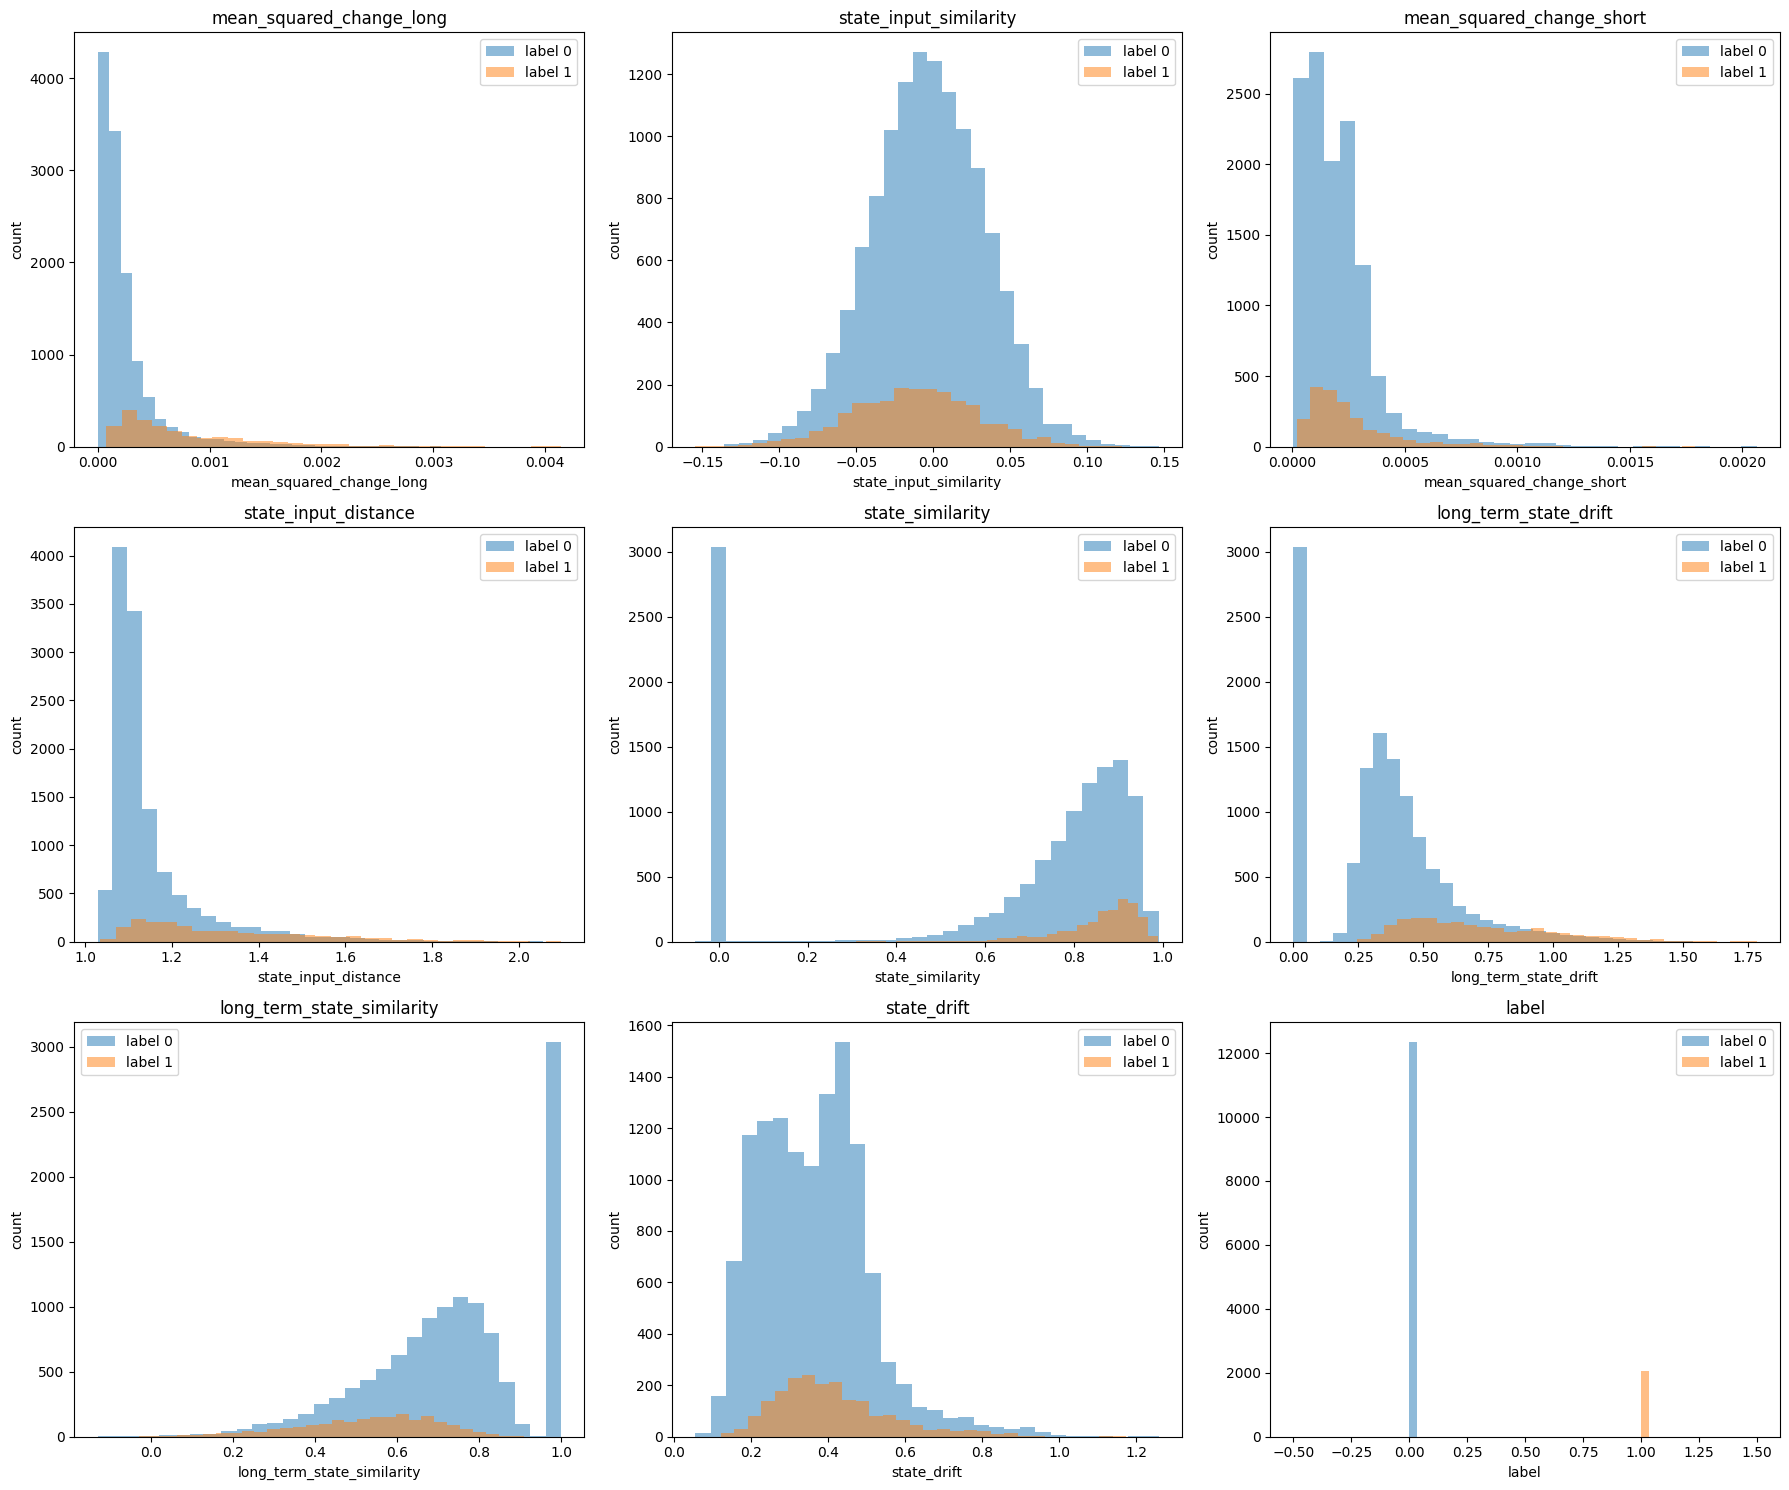

In [12]:
n_cols = 3
n_rows = int(np.ceil(len(feature_names) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(feature_names):
    ax = axes[i]

    for lbl in unique_labels:
        subset = df[df["label"] == lbl][feature]
        ax.hist(subset, bins=30, alpha=0.5, label=f"label {lbl}")

    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("count")
    ax.legend()

# remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [13]:
feature_names.pop()

'label'

In [14]:
feature_names

['mean_squared_change_long',
 'state_input_similarity',
 'mean_squared_change_short',
 'state_input_distance',
 'state_similarity',
 'long_term_state_drift',
 'long_term_state_similarity',
 'state_drift']

In [279]:
all_features = {}

for f in feature_names:
    orig = df[f].copy()
    all_features[f"{f}_orig"] = orig

    x = orig.copy()

    if x.min() <= 0:
        x = x +1 + 1e-6  

    all_features[f"{f}_log"] = np.log(x)
    all_features[f"{f}_sqrt"] = np.sqrt(x)
    all_features[f"{f}_boxcox"], _ = stats.boxcox(x)

In [280]:
df_trans = pd.DataFrame(all_features)
df_trans["label"] = df["label"]

In [281]:
df_trans.head()

,state_drift_orig,state_drift_log,state_drift_sqrt,state_drift_boxcox,mean_squared_change_short_orig,mean_squared_change_short_log,mean_squared_change_short_sqrt,mean_squared_change_short_boxcox,long_term_state_similarity_orig,long_term_state_similarity_log,...,long_term_state_drift_boxcox,mean_squared_change_long_orig,mean_squared_change_long_log,mean_squared_change_long_sqrt,mean_squared_change_long_boxcox,state_similarity_orig,state_similarity_log,state_similarity_sqrt,state_similarity_boxcox,label
0,0.449988,-0.798533,0.670812,-0.729352,0.000264,-8.240857,0.016238,-5.320289,1.000000,0.693148,...,9.999994e-07,0.000000,9.999995e-07,1.000000,9.986887e-07,0.000000,9.999995e-07,1.000000,0.000001,0
1,0.298725,-1.208231,0.546558,-1.054574,0.000116,-9.060251,0.010779,-5.622749,0.789470,0.581920,...,2.536426e-01,0.000116,1.171869e-04,1.000059,1.008837e-04,0.789470,5.819199e-01,1.337711,2.783111,0
2,0.216980,-1.527949,0.465811,-1.287872,0.000061,-9.699688,0.007830,-5.839720,0.680631,0.519170,...,2.976049e-01,0.000170,1.708260e-04,1.000085,1.376748e-04,0.889950,6.365507e-01,1.374755,3.613276,0
3,0.172313,-1.758443,0.415106,-1.445712,0.000039,-10.160675,0.006218,-5.986513,0.681603,0.519748,...,2.889315e-01,0.000158,1.591786e-04,1.000080,1.301200e-04,0.925097,6.549771e-01,1.387479,3.942130,0
4,0.178567,-1.722791,0.422572,-1.421843,0.000042,-10.089371,0.006443,-5.964314,0.656864,0.504928,...,3.025760e-01,0.000177,1.777508e-04,1.000089,1.420582e-04,0.914687,6.495546e-01,1.383722,3.842532,0


In [282]:
df_trans.columns.tolist()

['state_drift_orig',
 'state_drift_log',
 'state_drift_sqrt',
 'state_drift_boxcox',
 'mean_squared_change_short_orig',
 'mean_squared_change_short_log',
 'mean_squared_change_short_sqrt',
 'mean_squared_change_short_boxcox',
 'long_term_state_similarity_orig',
 'long_term_state_similarity_log',
 'long_term_state_similarity_sqrt',
 'long_term_state_similarity_boxcox',
 'state_input_distance_orig',
 'state_input_distance_log',
 'state_input_distance_sqrt',
 'state_input_distance_boxcox',
 'state_input_similarity_orig',
 'state_input_similarity_log',
 'state_input_similarity_sqrt',
 'state_input_similarity_boxcox',
 'long_term_state_drift_orig',
 'long_term_state_drift_log',
 'long_term_state_drift_sqrt',
 'long_term_state_drift_boxcox',
 'mean_squared_change_long_orig',
 'mean_squared_change_long_log',
 'mean_squared_change_long_sqrt',
 'mean_squared_change_long_boxcox',
 'state_similarity_orig',
 'state_similarity_log',
 'state_similarity_sqrt',
 'state_similarity_boxcox',
 'label']

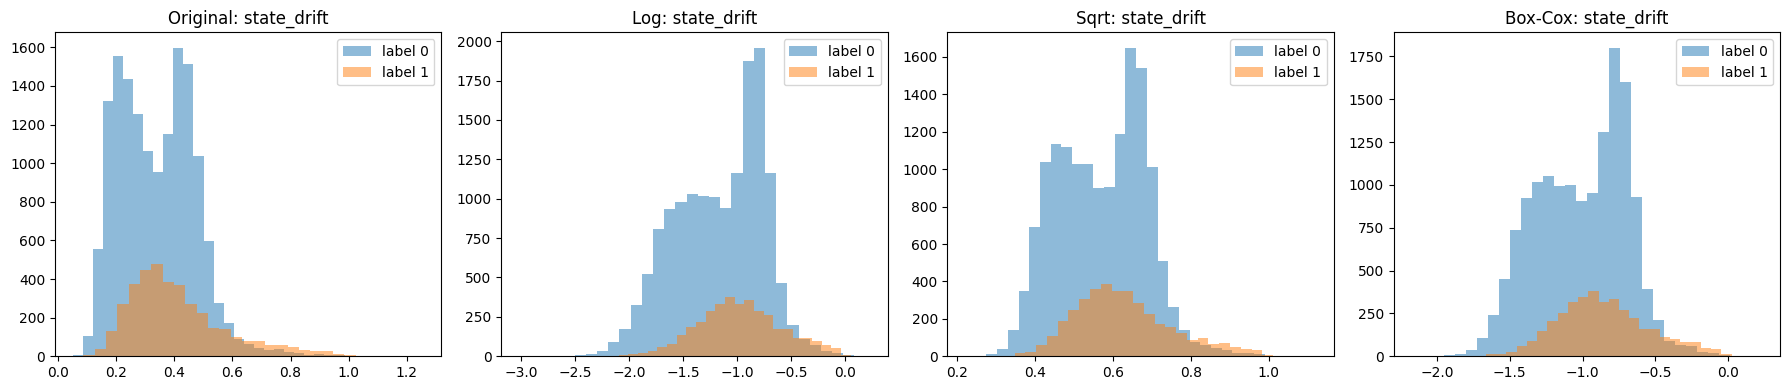

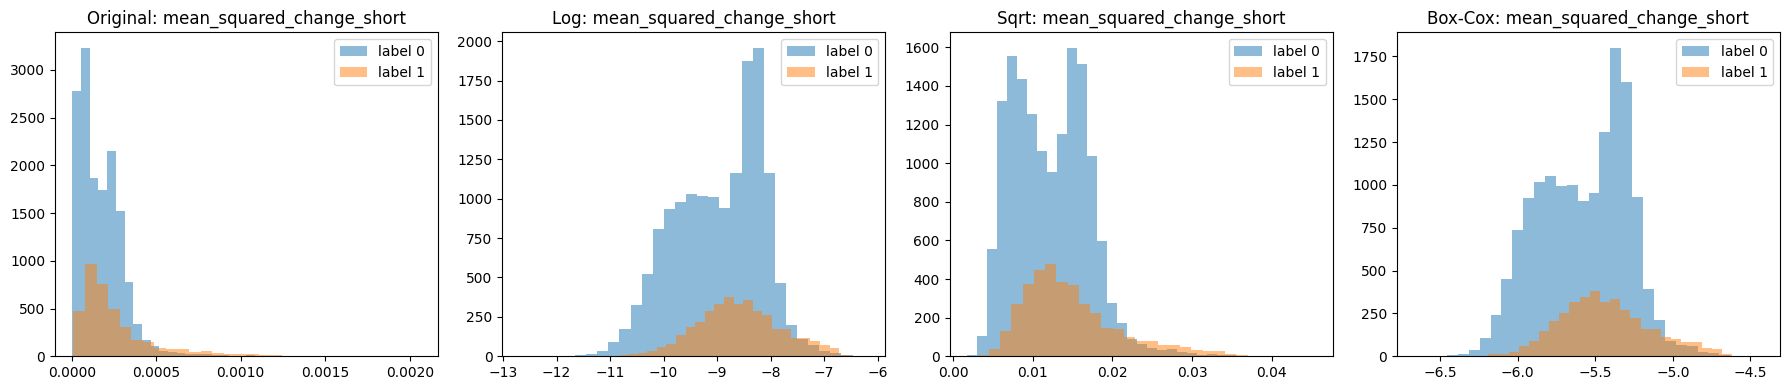

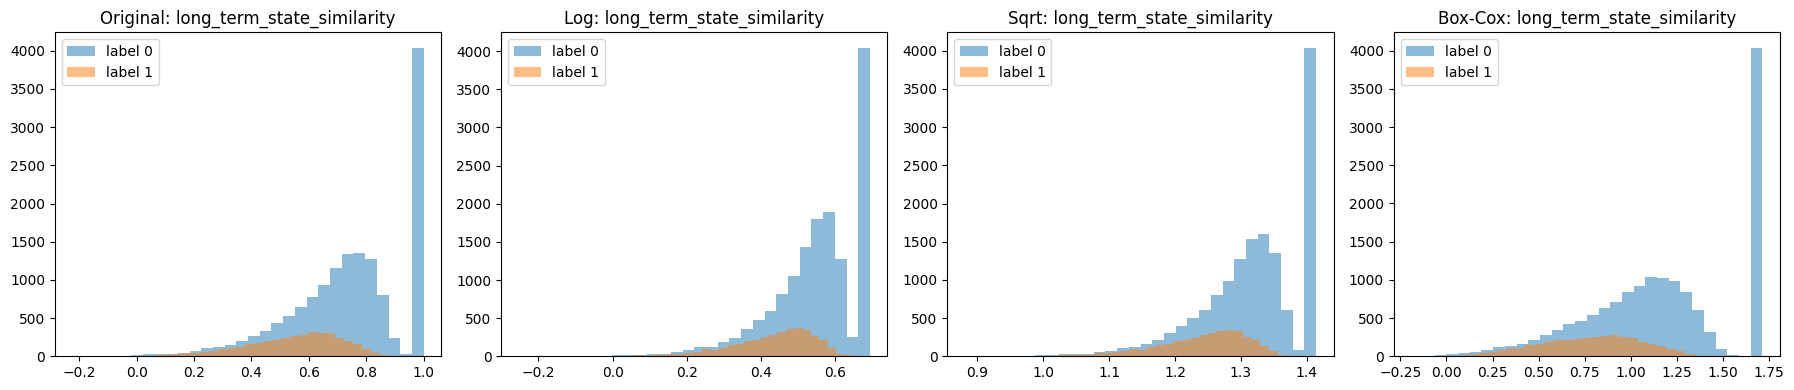

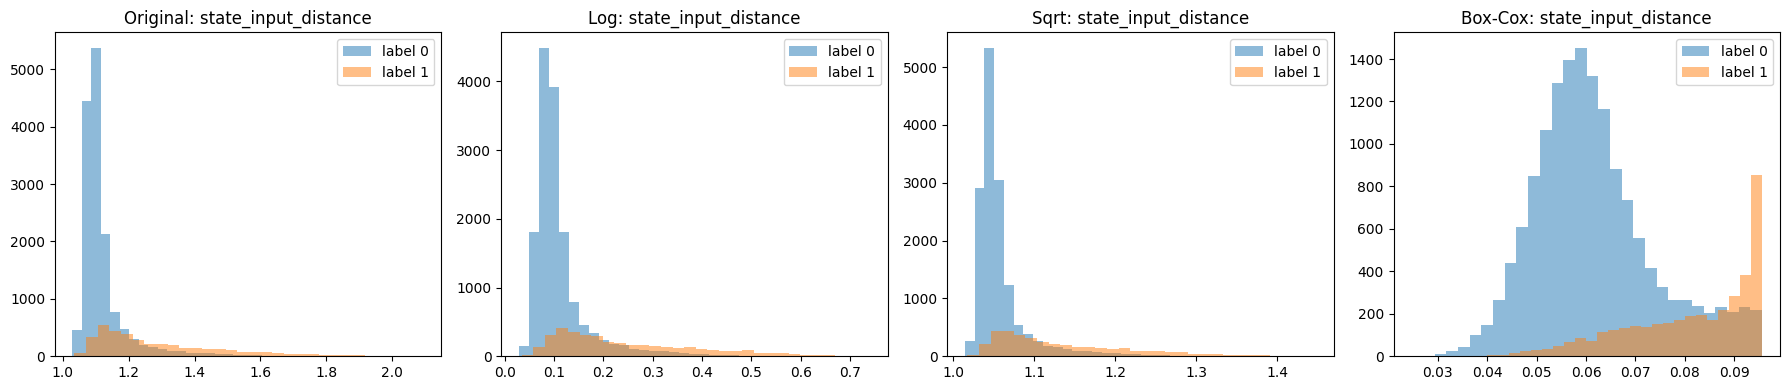

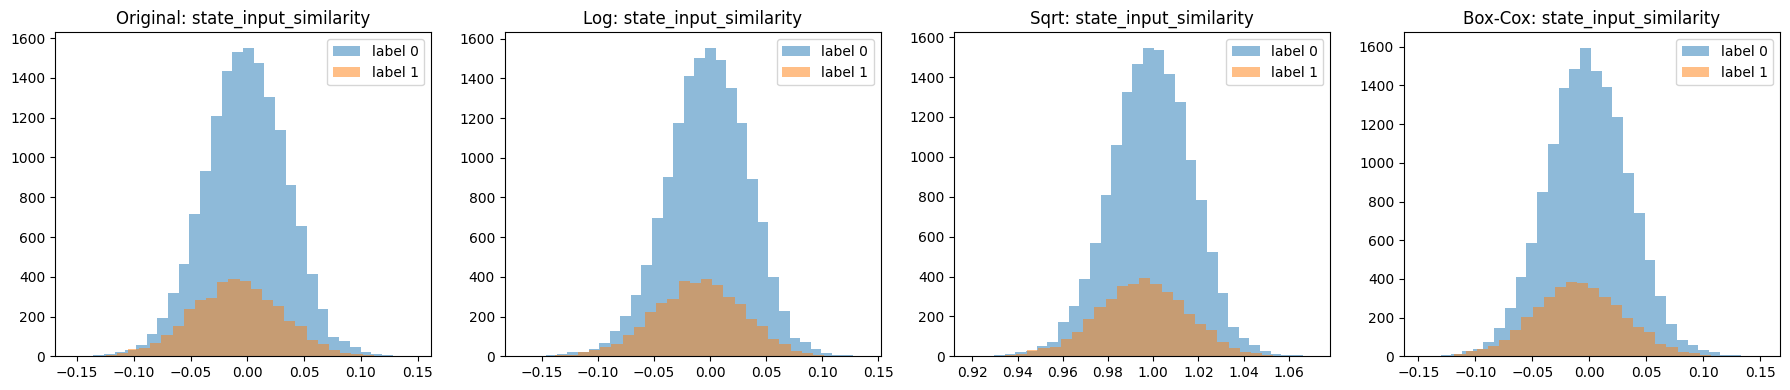

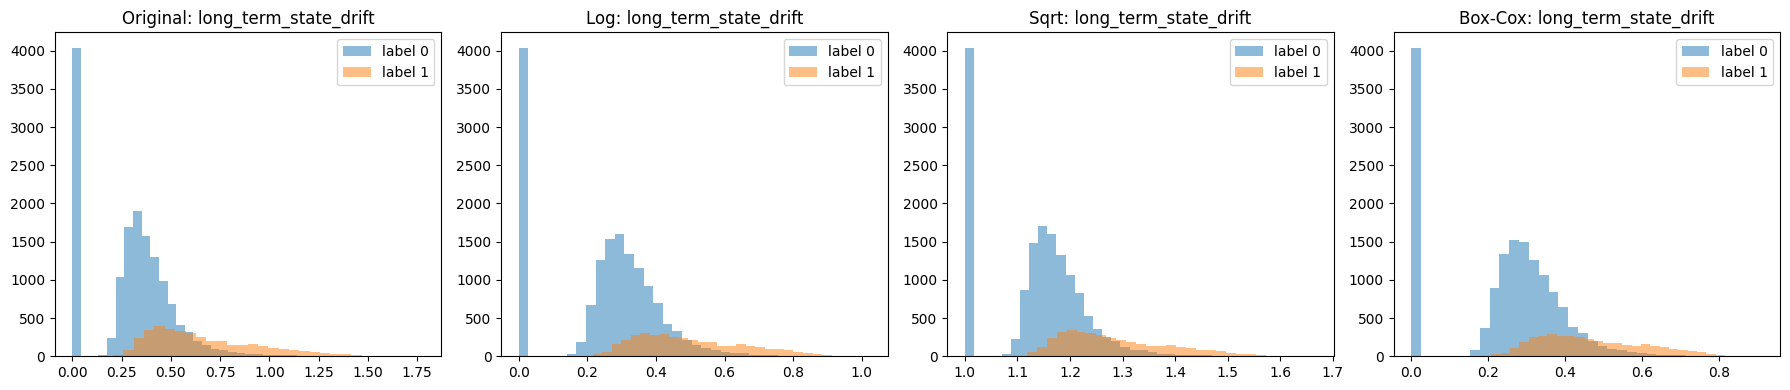

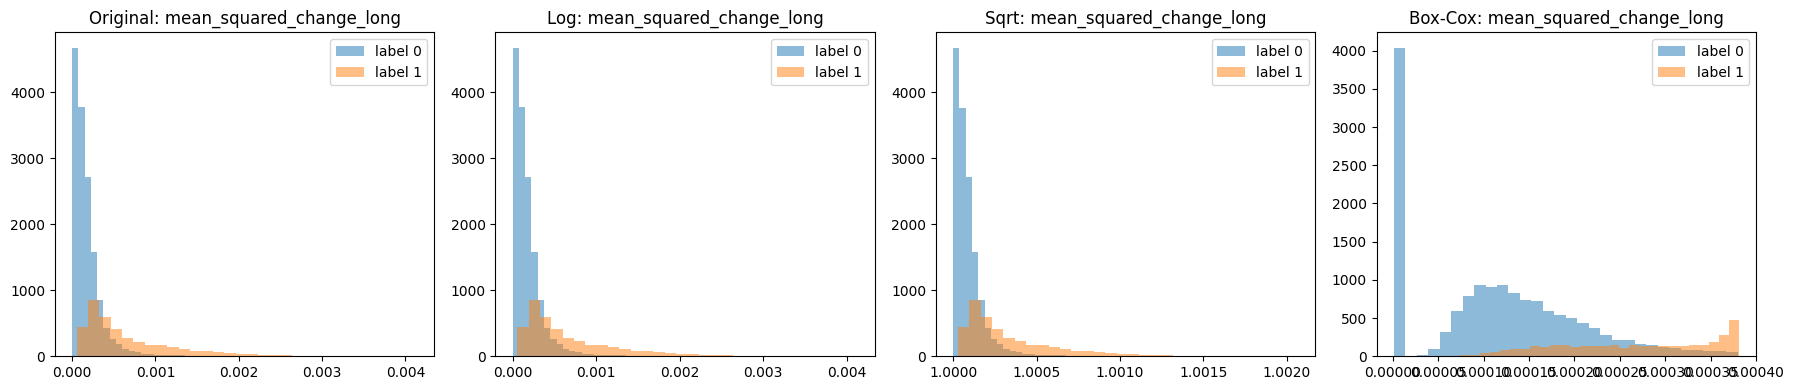

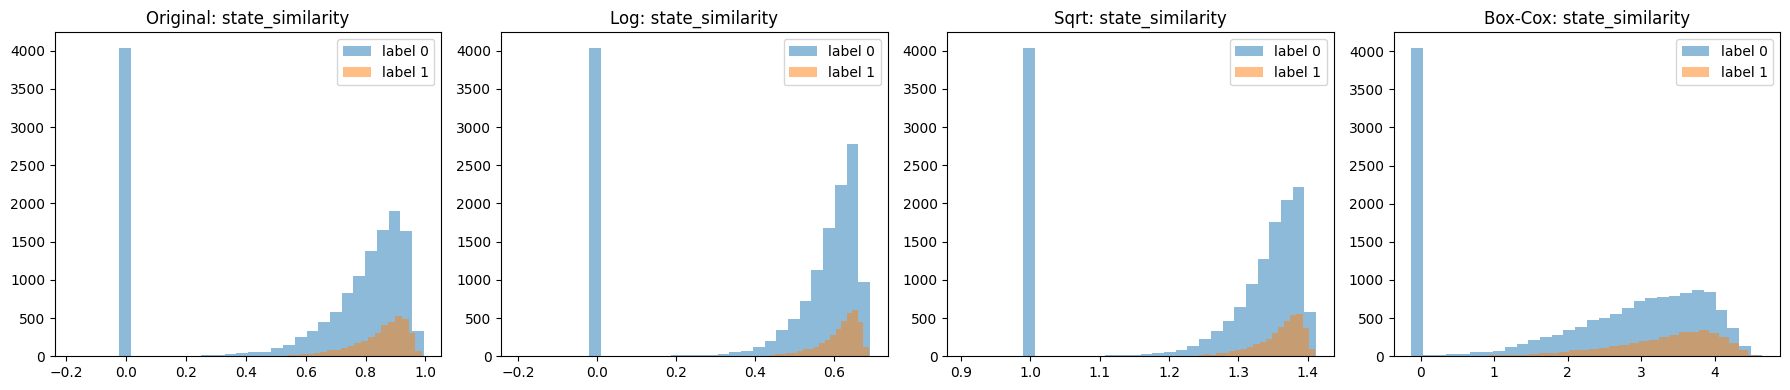

In [283]:
for feature in feature_names:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    for lbl in df_trans["label"].unique():
        subset = df_trans[df_trans["label"] == lbl][feature+"_orig"]
        axes[0].hist(subset, bins=30, alpha=0.5, label=f"label {lbl}")
        subset_log = df_trans[df_trans["label"] == lbl][f"{feature}_log"]
        axes[1].hist(subset_log, bins=30, alpha=0.5, label=f"label {lbl}")
        subset_sqrt = df_trans[df_trans["label"] == lbl][f"{feature}_sqrt"]
        axes[2].hist(subset_sqrt, bins=30, alpha=0.5, label=f"label {lbl}")
        subset_boxcox = df_trans[df_trans["label"] == lbl][f"{feature}_boxcox"]
        axes[3].hist(subset_boxcox, bins=30, alpha=0.5, label=f"label {lbl}")

    axes[0].set_title(f"Original: {feature}")
    axes[1].set_title(f"Log: {feature}")
    axes[2].set_title(f"Sqrt: {feature}")
    axes[3].set_title(f"Box-Cox: {feature}")

    for ax in axes:
        ax.legend()

    plt.tight_layout()
    plt.show()

In [284]:
df_trans = pd.DataFrame(all_features)
df_trans["label"] = df["label"]

In [285]:
df_trans

,state_drift_orig,state_drift_log,state_drift_sqrt,state_drift_boxcox,mean_squared_change_short_orig,mean_squared_change_short_log,mean_squared_change_short_sqrt,mean_squared_change_short_boxcox,long_term_state_similarity_orig,long_term_state_similarity_log,...,long_term_state_drift_boxcox,mean_squared_change_long_orig,mean_squared_change_long_log,mean_squared_change_long_sqrt,mean_squared_change_long_boxcox,state_similarity_orig,state_similarity_log,state_similarity_sqrt,state_similarity_boxcox,label
0,0.449988,-0.798533,0.670812,-0.729352,0.000264,-8.240857,0.016238,-5.320289,1.000000,0.693148,...,9.999994e-07,0.000000,9.999995e-07,1.000000,9.986887e-07,0.000000,9.999995e-07,1.000000,0.000001,0
1,0.298725,-1.208231,0.546558,-1.054574,0.000116,-9.060251,0.010779,-5.622749,0.789470,0.581920,...,2.536426e-01,0.000116,1.171869e-04,1.000059,1.008837e-04,0.789470,5.819199e-01,1.337711,2.783111,0
2,0.216980,-1.527949,0.465811,-1.287872,0.000061,-9.699688,0.007830,-5.839720,0.680631,0.519170,...,2.976049e-01,0.000170,1.708260e-04,1.000085,1.376748e-04,0.889950,6.365507e-01,1.374755,3.613276,0
3,0.172313,-1.758443,0.415106,-1.445712,0.000039,-10.160675,0.006218,-5.986513,0.681603,0.519748,...,2.889315e-01,0.000158,1.591786e-04,1.000080,1.301200e-04,0.925097,6.549771e-01,1.387479,3.942130,0
4,0.178567,-1.722791,0.422572,-1.421843,0.000042,-10.089371,0.006443,-5.964314,0.656864,0.504928,...,3.025760e-01,0.000177,1.777508e-04,1.000089,1.420582e-04,0.914687,6.495546e-01,1.383722,3.842532,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18753,0.447068,-0.805045,0.668631,-0.734765,0.000260,-8.253881,0.016132,-5.325323,1.000000,0.693148,...,9.999994e-07,0.000000,9.999995e-07,1.000000,9.986887e-07,0.000000,9.999995e-07,1.000000,0.000001,0
18754,0.591394,-0.525273,0.769021,-0.494720,0.000455,-7.694337,0.021340,-5.102078,0.730425,0.548367,...,4.405265e-01,0.000455,4.562949e-04,1.000228,2.660141e-04,0.730425,5.483675e-01,1.315456,2.364958,0
18755,0.419512,-0.868664,0.647697,-0.787223,0.000229,-8.381117,0.015138,-5.374110,0.644762,0.497596,...,5.608874e-01,0.000883,8.835525e-04,1.000442,3.436057e-04,0.922363,6.535557e-01,1.386493,3.915790,0
18756,0.586216,-0.534068,0.765647,-0.502503,0.000447,-7.711925,0.021153,-5.109317,0.645718,0.498177,...,4.253898e-01,0.000415,4.163497e-04,1.000208,2.532945e-04,0.834031,6.065169e-01,1.354264,3.131970,1


In [286]:
corr_with_label = df_trans.corr(method="pearson")["label"].drop("label")

In [287]:
print(corr_with_label)

state_drift_orig                     0.208607
state_drift_log                      0.194791
state_drift_sqrt                     0.201860
state_drift_boxcox                   0.198061
mean_squared_change_short_orig       0.217822
mean_squared_change_short_log        0.194791
mean_squared_change_short_sqrt       0.208607
mean_squared_change_short_boxcox     0.198061
long_term_state_similarity_orig     -0.382121
long_term_state_similarity_log      -0.371577
long_term_state_similarity_sqrt     -0.377576
long_term_state_similarity_boxcox   -0.388306
state_input_distance_orig            0.539544
state_input_distance_log             0.551323
state_input_distance_sqrt            0.545939
state_input_distance_boxcox          0.537930
state_input_similarity_orig         -0.088058
state_input_similarity_log          -0.089621
state_input_similarity_sqrt         -0.088847
state_input_similarity_boxcox       -0.087169
long_term_state_drift_orig           0.559782
long_term_state_drift_log         

In [288]:
best_features_corr = []

for f in feature_names:
    candidates = {
        "orig": corr_with_label.get(f"{f}_orig", 0),
        "log": corr_with_label.get(f"{f}_log", 0),
        "sqrt": corr_with_label.get(f"{f}_sqrt", 0),
        "boxcox": corr_with_label.get(f"{f}_boxcox", 0),
    }
    best_variant = max(candidates, key=lambda k: abs(candidates[k]))
    best_features_corr.append(f"{f}_{best_variant}")

In [289]:
best_features_corr

['state_drift_orig',
 'mean_squared_change_short_orig',
 'long_term_state_similarity_boxcox',
 'state_input_distance_log',
 'state_input_similarity_log',
 'long_term_state_drift_orig',
 'mean_squared_change_long_boxcox',
 'state_similarity_boxcox']

In [290]:
best_features = []
feature_scores = {}

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

for f in feature_names:
    candidates = {
        f"{f}_orig": all_features[f"{f}_orig"],
        f"{f}_log": all_features[f"{f}_log"],
        f"{f}_sqrt": all_features[f"{f}_sqrt"],
        f"{f}_boxcox": all_features[f"{f}_boxcox"]
    }

    best_score = -np.inf
    best_version = None

    for name, feat in candidates.items():
        X_temp = np.array(feat).reshape(-1, 1)
        if np.any(np.isnan(X_temp)) or np.any(np.isinf(X_temp)):
            continue
        score = cross_val_score(model,X_temp,df["label"],cv=5,scoring="f1").mean()

        if score > best_score:
            best_score = score
            best_version = name

    best_features.append(best_version)
    feature_scores[f] = {
        "best_version": best_version,
        "best_score": best_score
    }

In [291]:
best_features

['state_drift_boxcox',
 'mean_squared_change_short_log',
 'long_term_state_similarity_orig',
 'state_input_distance_sqrt',
 'state_input_similarity_log',
 'long_term_state_drift_log',
 'mean_squared_change_long_boxcox',
 'state_similarity_boxcox']

In [292]:
X = df_trans[best_features]
y = df_trans["label"]

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X, y)

importances = model.feature_importances_

feature_importance = sorted(
    zip(X.columns, importances),
    key=lambda x: x[1],
    reverse=True
)

for f, imp in feature_importance:
    print(f"{f}: {imp:.4f}")

long_term_state_drift_log: 0.1900
state_input_distance_sqrt: 0.1785
mean_squared_change_long_boxcox: 0.1421
long_term_state_similarity_orig: 0.1253
state_similarity_boxcox: 0.1178
state_drift_boxcox: 0.0924
mean_squared_change_short_log: 0.0909
state_input_similarity_log: 0.0630


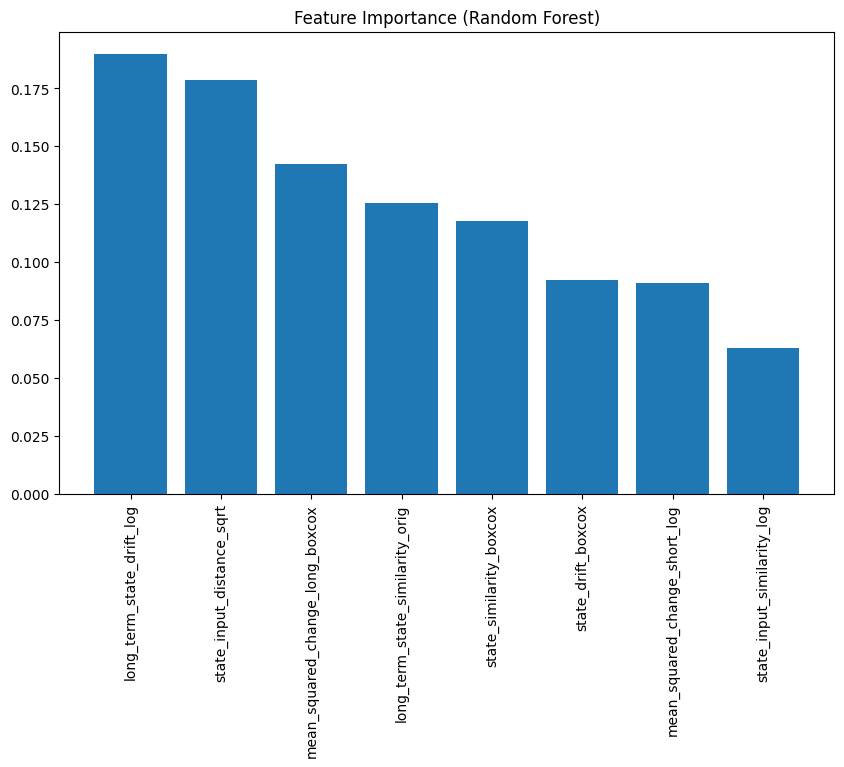

In [293]:
names = [f for f, _ in feature_importance]
values = [imp for _, imp in feature_importance]

plt.figure(figsize=(10, 6))
plt.bar(names, values)
plt.xticks(rotation=90)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [294]:
df_trans

,state_drift_orig,state_drift_log,state_drift_sqrt,state_drift_boxcox,mean_squared_change_short_orig,mean_squared_change_short_log,mean_squared_change_short_sqrt,mean_squared_change_short_boxcox,long_term_state_similarity_orig,long_term_state_similarity_log,...,long_term_state_drift_boxcox,mean_squared_change_long_orig,mean_squared_change_long_log,mean_squared_change_long_sqrt,mean_squared_change_long_boxcox,state_similarity_orig,state_similarity_log,state_similarity_sqrt,state_similarity_boxcox,label
0,0.449988,-0.798533,0.670812,-0.729352,0.000264,-8.240857,0.016238,-5.320289,1.000000,0.693148,...,9.999994e-07,0.000000,9.999995e-07,1.000000,9.986887e-07,0.000000,9.999995e-07,1.000000,0.000001,0
1,0.298725,-1.208231,0.546558,-1.054574,0.000116,-9.060251,0.010779,-5.622749,0.789470,0.581920,...,2.536426e-01,0.000116,1.171869e-04,1.000059,1.008837e-04,0.789470,5.819199e-01,1.337711,2.783111,0
2,0.216980,-1.527949,0.465811,-1.287872,0.000061,-9.699688,0.007830,-5.839720,0.680631,0.519170,...,2.976049e-01,0.000170,1.708260e-04,1.000085,1.376748e-04,0.889950,6.365507e-01,1.374755,3.613276,0
3,0.172313,-1.758443,0.415106,-1.445712,0.000039,-10.160675,0.006218,-5.986513,0.681603,0.519748,...,2.889315e-01,0.000158,1.591786e-04,1.000080,1.301200e-04,0.925097,6.549771e-01,1.387479,3.942130,0
4,0.178567,-1.722791,0.422572,-1.421843,0.000042,-10.089371,0.006443,-5.964314,0.656864,0.504928,...,3.025760e-01,0.000177,1.777508e-04,1.000089,1.420582e-04,0.914687,6.495546e-01,1.383722,3.842532,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18753,0.447068,-0.805045,0.668631,-0.734765,0.000260,-8.253881,0.016132,-5.325323,1.000000,0.693148,...,9.999994e-07,0.000000,9.999995e-07,1.000000,9.986887e-07,0.000000,9.999995e-07,1.000000,0.000001,0
18754,0.591394,-0.525273,0.769021,-0.494720,0.000455,-7.694337,0.021340,-5.102078,0.730425,0.548367,...,4.405265e-01,0.000455,4.562949e-04,1.000228,2.660141e-04,0.730425,5.483675e-01,1.315456,2.364958,0
18755,0.419512,-0.868664,0.647697,-0.787223,0.000229,-8.381117,0.015138,-5.374110,0.644762,0.497596,...,5.608874e-01,0.000883,8.835525e-04,1.000442,3.436057e-04,0.922363,6.535557e-01,1.386493,3.915790,0
18756,0.586216,-0.534068,0.765647,-0.502503,0.000447,-7.711925,0.021153,-5.109317,0.645718,0.498177,...,4.253898e-01,0.000415,4.163497e-04,1.000208,2.532945e-04,0.834031,6.065169e-01,1.354264,3.131970,1


In [298]:
selected_features = [
    'long_term_state_drift_log',
    'state_input_distance_sqrt',
    'mean_squared_change_short_boxcox',
    'long_term_state_similarity_orig',
    'state_similarity_boxcox'
]

In [299]:
df_trans[selected_features].head()

,long_term_state_drift_log,state_input_distance_sqrt,mean_squared_change_short_boxcox,long_term_state_similarity_orig,state_similarity_boxcox
0,9.999995e-07,1.042241,-5.320289,1.000000,0.000001
1,2.613841e-01,1.052948,-5.622749,0.789470,2.783111
2,3.083390e-01,1.051170,-5.839720,0.680631,3.613276
3,2.990347e-01,1.042976,-5.986513,0.681603,3.942130
4,3.136807e-01,1.036824,-5.964314,0.656864,3.842532


In [300]:
original_cols=vector_list+["y"]

In [301]:
df_final=pd.concat([df_all[original_cols], df_trans[selected_features]], axis=1)

In [302]:
df_final

,0,1,2,3,4,5,6,7,8,9,...,1534,1535,conv_id,turn_id,y,long_term_state_drift_log,state_input_distance_sqrt,mean_squared_change_short_boxcox,long_term_state_similarity_orig,state_similarity_boxcox
0,0.022156,0.009600,-0.005651,0.037142,0.026982,0.014868,-0.013620,-0.011513,0.020963,-0.005187,...,-0.038129,-0.020168,0.0,0.0,0,9.999995e-07,1.042241,-5.320289,1.000000,0.000001
1,0.033551,0.014626,-0.013005,0.029625,0.038335,-0.000664,-0.020039,-0.016444,0.017359,0.001949,...,0.001111,0.016277,0.0,1.0,0,2.613841e-01,1.052948,-5.622749,0.789470,2.783111
2,0.028587,0.021823,-0.007307,0.023240,0.034987,-0.015518,-0.027399,-0.020127,0.009395,-0.001386,...,0.015822,0.000744,0.0,2.0,0,3.083390e-01,1.051170,-5.839720,0.680631,3.613276
3,0.014920,0.008290,-0.004189,0.028177,0.026437,-0.005988,-0.020008,-0.018204,0.015614,0.006017,...,0.004717,-0.005025,0.0,3.0,0,2.990347e-01,1.042976,-5.986513,0.681603,3.942130
4,0.018797,0.009575,0.000537,0.024246,0.037969,-0.012389,-0.027038,-0.023365,0.010820,0.000679,...,-0.010719,-0.002960,0.0,4.0,0,3.136807e-01,1.036824,-5.964314,0.656864,3.842532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18753,-0.039515,-0.010074,0.023661,0.012855,0.003421,-0.014791,-0.001751,-0.013007,-0.003218,0.023564,...,0.032729,0.041474,4036.0,0.0,0,9.999995e-07,1.055633,-5.325323,1.000000,0.000001
18754,-0.025135,-0.037671,0.049991,0.015364,0.017914,-0.003555,-0.016524,-0.040135,0.000613,0.039743,...,-0.042925,0.051836,4036.0,1.0,0,4.646108e-01,1.146465,-5.102078,0.730425,2.364958
18755,-0.045876,-0.045405,0.060885,0.009341,0.021263,-0.006970,-0.020927,-0.049787,-0.003796,0.040816,...,0.044166,0.005600,4036.0,2.0,0,6.007409e-01,1.209875,-5.374110,0.644762,3.915790
18756,-0.025517,-0.023269,0.039099,-0.018240,0.013294,-0.007832,-0.033553,-0.047526,-0.006112,0.039862,...,-0.021671,0.021756,4036.0,3.0,1,4.477904e-01,1.123392,-5.109317,0.645718,3.131970


In [ ]:
df_final.to_csv("./../data/ssm_final_features_new_data_new_label.csv", index=False)